In this notebook, 

    - clean and provide some stats for DP1 data
    - refine fitting procedure
    - batch processing with dash
    - benchmarking for batch processing

In [1]:
%pip install lsdb hats nested_pandas --upgrade
%pip install arviz
%pip install eztaox
%pip install astropy --upgrade

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [2]:
from upath import UPath

from matplotlib.patches import Patch
import matplotlib.pyplot as plt
import numpy as np
import arviz as az

import numpyro
import numpyro.distributions as dist
import jax.numpy as jnp
import jax
import nested_pandas as npd
from nested_pandas import NestedDtype
import pyarrow as pa

from numpyro.infer import MCMC, NUTS, init_to_median
from numpyro.handlers import seed as numpyro_seed

import lsdb
from eztaox.kernels.quasisep import Exp, MultibandLowRank
from eztaox.models import MultiVarModel
from eztaox.fitter import random_search

from dask.distributed import Client
import pandas as pd
from nested_pandas import NestedFrame

## DP1 cleaning and stats

In [3]:
base_path = UPath("/rubin/lsdb_data")
dia_object_cat = lsdb.open_catalog(base_path / "dia_object_collection", \
                                   columns = ['ra', 'dec', 'diaObjectId', 'nDiaSources', 'diaObjectForcedSource'],\
                                  filters=[["nDiaSources", ">", 10]])
print("number of DIA objects in DP1:", len(dia_object_cat))

number of DIA objects in DP1: 1089818


In [4]:
dia_object_cat.head()

ra       dec         diaObjectId  nDiaSources  \
_healpix_29                                                              
9199596288106482  38.220207   6.19294  648370049710555138           11   
9200141817748620  38.347676  6.225814  648370668185845779           12   
9200528411122949  38.353107  6.240326  648370668185845777           11   
9200631826218945  38.304412   6.24801  648370736905322531           13   
9200674673296460  38.331506  6.261087  648370736905322556           12   

                                              diaObjectForcedSource  
_healpix_29                                                          
9199596288106482  [{parentObjectId: 0, coord_ra: 38.220207, coor...  
9200141817748620  [{parentObjectId: 0, coord_ra: 38.347676, coor...  
9200528411122949  [{parentObjectId: 0, coord_ra: 38.353107, coor...  
9200631826218945  [{parentObjectId: 0, coord_ra: 38.304412, coor...  
9200674673296460  [{parentObjectId: 0, coord_ra: 38.331506, coor...

In [5]:
dia_object_cat['diaObjectForcedSource'].columns

['parentObjectId',
 'coord_ra',
 'coord_dec',
 'visit',
 'detector',
 'band',
 'psfFlux',
 'psfFluxErr',
 'psfFlux_flag',
 'psfDiffFlux',
 'psfDiffFluxErr',
 'psfDiffFlux_flag',
 'diff_PixelFlags_nodataCenter',
 'pixelFlags_bad',
 'pixelFlags_cr',
 'pixelFlags_crCenter',
 'pixelFlags_edge',
 'pixelFlags_interpolated',
 'pixelFlags_interpolatedCenter',
 'pixelFlags_nodata',
 'pixelFlags_saturated',
 'pixelFlags_saturatedCenter',
 'pixelFlags_suspect',
 'pixelFlags_suspectCenter',
 'invalidPsfFlag',
 'tract',
 'patch',
 'forcedSourceOnDiaObjectId',
 'psfMag',
 'psfMagErr',
 'midpointMjdTai']

In [6]:
## remove flags
flag_subcols = [c for c in dia_object_cat["diaObjectForcedSource"].columns if "Flag" in c]
expr = " and ".join([f"diaObjectForcedSource.{c} != 1" for c in flag_subcols])
dia_object_cat = dia_object_cat.query(expr)
dia_object_cat = dia_object_cat.map_partitions(lambda df: df.dropna(subset=["diaObjectForcedSource"]))

In [7]:
#dia_object_cat = dia_object_cat.map_rows(
#    len,
#    columns=["diaObjectForcedSource.band"],
#    row_container="args",
#    output_names=["nClean"],
#    meta={"nClean": int},
#    append_columns=True,
#)

In [8]:
## drop clean 
#dia_object_cat = dia_object_cat.query("nClean >= 100")

In [9]:
#with Client(n_workers=4):
#    dia_object_clean = dia_object_cat.compute()

In [10]:
dia_object_cat.head(20)

ra       dec         diaObjectId  nDiaSources  \
_healpix_29                                                              
9199596288106482  38.220207   6.19294  648370049710555138           11   
9200141817748620  38.347676  6.225814  648370668185845779           12   
9200528411122949  38.353107  6.240326  648370668185845777           11   
9200631826218945  38.304412   6.24801  648370736905322531           13   
9200674673296460  38.331506  6.261087  648370736905322556           12   
9212348041938716  38.395793  6.277232  648370668185845770           13   
9212640873434193  38.424909  6.314523  648370668185845784           12   
9212723264655744  38.388479  6.320332  648370668185845765           13   
9212728205600829  38.394516  6.326363  648370668185845783           14   
9213258196944477   38.50881  6.351814  648370599466369032           11   
9213556865037690  38.426039  6.362682  648371355380613203           11   
9213611528300146  38.441481  6.375415  648371355380613146           20   
9213799940800652  38.478755   6.39498  648371355380613144           14   
9572200614202882  38.080629  6.175482  648362628007067650           15   
9572240941951962  38.046666  6.167692  648362628007067651           14   
9573890550572346  38.002791  6.206548  648363383921311790           13   
9573963269827128  38.002332  6.215159  648363383921311787           15   
9574257910414122  37.920853  6.227211  648363383921311784           17   
9574296389143013  37.984541  6.223281  648363383921311786           12   
9574324204772895   37.97046  6.224633  648363383921311785           12   

                                              diaObjectForcedSource  
_healpix_29                                                          
9199596288106482  [{parentObjectId: 0, coord_ra: 38.220207, coor...  
9200141817748620  [{parentObjectId: 0, coord_ra: 38.347676, coor...  
9200528411122949  [{parentObjectId: 0, coord_ra: 38.353107, coor...  
9200631826218945  [{parentObjectId: 0, coord_ra: 38.304412, coor...  
9200674673296460  [{parentObjectId: 0, coord_ra: 38.331506, coor...  
9212348041938716  [{parentObjectId: 0, coord_ra: 38.395793, coor...  
9212640873434193  [{parentObjectId: 0, coord_ra: 38.424909, coor...  
9212723264655744  [{parentObjectId: 0, coord_ra: 38.388479, coor...  
9212728205600829  [{parentObjectId: 0, coord_ra: 38.394516, coor...  
9213258196944477  [{parentObjectId: 0, coord_ra: 38.50881, coord...  
9213556865037690  [{parentObjectId: 0, coord_ra: 38.426039, coor...  
9213611528300146  [{parentObjectId: 0, coord_ra: 38.441481, coor...  
9213799940800652  [{parentObjectId: 0, coord_ra: 38.478755, coor...  
9572200614202882  [{parentObjectId: 0, coord_ra: 38.080629, coor...  
9572240941951962  [{parentObjectId: 0, coord_ra: 38.046666, coor...  
9573890550572346  [{parentObjectId: 0, coord_ra: 38.002791, coor...  
9573963269827128  [{parentObjectId: 0, coord_ra: 38.002332, coor...  
9574257910414122  [{parentObjectId: 0, coord_ra: 37.920853, coor...  
9574296389143013  [{parentObjectId: 0, coord_ra: 37.984541, coor...  
9574324204772895  [{parentObjectId: 0, coord_ra: 37.97046, coord...

In [11]:
dia_object_cat

,ra,dec,diaObjectId,nDiaSources,diaObjectForcedSource
npartitions=208,,,,,
"Order: 6, Pixel: 130",double[pyarrow],double[pyarrow],int64[pyarrow],int64[pyarrow],"nested<parentObjectId: [int64], coord_ra: [dou..."
"Order: 6, Pixel: 136",...,...,...,...,...
...,...,...,...,...,...
"Order: 11, Pixel: 36833621",...,...,...,...,...
"Order: 7, Pixel: 143884",...,...,...,...,...


In [12]:
df_head = dia_object_cat.head(100)
#df_head.iloc[0]['diaObjectForcedSource']
df_head['nDiaSources'].values

<ArrowExtensionArray>
[11, 12, 11, 13, 12, 13, 12, 13, 14, 11, 11, 20, 14, 15, 14, 13, 15, 17, 12,
 12, 20, 16, 15, 12, 15, 11, 13, 18, 11, 12, 20, 11, 19, 17, 21, 24, 16, 23,
 14, 18, 15, 26, 28, 14, 16, 18, 14, 22, 26, 22, 18, 23, 13, 21, 32, 27, 25,
 26, 11, 33, 26, 19, 27, 13, 20, 29, 32, 32, 33, 21, 33, 35, 15, 14, 35, 21,
 11, 14, 14, 19, 20, 15, 17, 11, 14, 24, 21, 13, 14, 12, 16, 14, 13, 27, 17,
 19, 27, 31, 22, 16]
Length: 100, dtype: int64[pyarrow]

/opt/lsst/software/stack/conda/envs/lsst-scipipe-10.1.0-exact/lib/python3.12/site-packages/dask/dataframe/dask_expr/_collection.py:1435: UserWarning: Dask currently has limited support for converting pandas extension dtypes to arrays. Converting int64[pyarrow] to object dtype.
  warnings.warn(
/opt/lsst/software/stack/conda/envs/lsst-scipipe-10.1.0-exact/lib/python3.12/site-packages/dask/dataframe/dask_expr/_collection.py:1435: UserWarning: Dask currently has limited support for converting pandas extension dtypes to arrays. Converting int64[pyarrow] to object dtype.
  warnings.warn(


Text(0, 0.5, 'Counts')

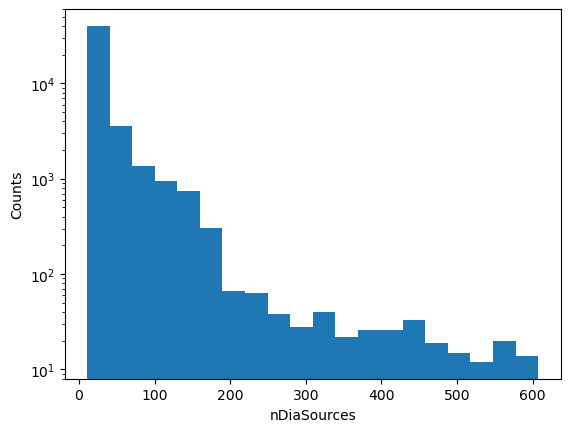

In [13]:
plt.hist(dia_object_cat['nDiaSources'],bins=20)
plt.yscale('log')
plt.xlabel('nDiaSources')
plt.ylabel('Counts')

In [16]:
def clean_lightcurves(time, band, mag, magerr, filter_bands = None, outlier_snr = 10, binning=True):
    times, bands, mags, magerrs = np.array([]), np.array([]), np.array([]), np.array([])

    #print(lightcurve)
    #time, band, mag, magerr = lightcurve
    #print(time, band, mag, magerr)
    ind = np.where(np.all([np.isfinite(time),np.isfinite(mag),np.isfinite(magerr)],axis=0))[0]
    time = np.array(time[ind])
    band = np.array(band[ind])
    mag = np.array(mag[ind])
    magerr = np.array(magerr[ind])

    #print('raw ndata',len(time))
    if len(time) == 0:
        return (
            np.array([], dtype=float),
            np.array([], dtype=str),
            np.array([], dtype=float),
            np.array([], dtype=float),
        )

    for b in np.unique(band):
        mask = band == b
        #print(band)
        time_band = time[mask]
        mag_band = mag[mask]
        magerr_band = magerr[mask]

        #print('filter bands', time_band, mag_band, magerr_band)
        
        # Remove 10 sigma outliers in each band
        if len(time_band)>1 and np.nanstd(mag_band) > 0:
            sigma = np.abs(mag_band - np.nanmean(mag_band)) / np.nanstd(mag_band)
            sigma_mask = sigma < outlier_snr
            time_band = time_band[sigma_mask]
            mag_band = mag_band[sigma_mask]
            magerr_band = magerr_band[sigma_mask]

        #print('sigma removal', time_band, mag_band, magerr_band)

        # Get mean mag and magerr for each unique epoch
        if binning:
            time_band_binned = np.unique(np.round(time_band))
            bands_binned = np.full(len(time_band_binned), b)
            times = np.append(times, time_band_binned)
            bands = np.append(bands, bands_binned)
            #print('binned band',bands_binned)
        
            for epoch in time_band_binned:
                epoch_mask = np.round(time_band) == epoch
                tmp_mag, tmp_err = combine_mag(mag_band[epoch_mask], magerr_band[epoch_mask])
                mags = np.append(mags, tmp_mag)
                magerrs = np.append(magerrs, tmp_err)
        else:
            times = np.append(times, time_band)
            bands = np.append(bands, np.full(len(time_band), b))
            mags = np.append(mags, mag_band)
            magerrs = np.append(magerrs, magerr_band)

        #print('after binning (if true)', times, bands, mags, magerrs)
        
    ind_sort = np.argsort(times)
    #print('clean ndata',len(times[ind_sort]))
    return (
        np.asarray(times[ind_sort], dtype=float),
        np.asarray(bands[ind_sort], dtype=str),
        np.asarray(mags[ind_sort], dtype=float),
        np.asarray(magerrs[ind_sort], dtype=float),
    )

    
def combine_mag(mag, mag_err):
    ## add in quaduature mean(magerr) and std(mag) in each epoch
    ## e.g., https://arxiv.org/abs/2411.06617
    mag = np.asarray(mag)
    mag_err = np.asarray(mag_err)
    mag_w = np.nanmean(mag)
    mag_w_err = np.sqrt(np.nanmean(mag_err) ** 2 + np.nanstd(mag) ** 2)
    return mag_w, mag_w_err



In [17]:
dia_object_clean = df_head.map_rows(
    clean_lightcurves,
    columns=[
        "diaObjectForcedSource.midpointMjdTai",
        "diaObjectForcedSource.band",
        "diaObjectForcedSource.psfMag",
        "diaObjectForcedSource.psfMagErr",
    ],
    row_container="args",
    output_names=[
        "cleanLC.Mjd",
        "cleanLC.Band",
        "cleanLC.Mag",
        "cleanLC.MagErr",
    ],
    infer_nesting=True,
    append_columns=True,
    binning=True,
)

dia_object_clean

ra       dec         diaObjectId  nDiaSources  \
_healpix_29                                                              
9199596288106482  38.220207   6.19294  648370049710555138           11   
9200141817748620  38.347676  6.225814  648370668185845779           12   
...                     ...       ...                 ...          ...   
9582660881222223   37.82159  6.342734  648363452640788531           22   
9582710344091213  37.813173   6.35942  648363452640788505           16   

                                              diaObjectForcedSource  \
_healpix_29                                                           
9199596288106482  [{parentObjectId: 0, coord_ra: 38.220207, coor...   
9200141817748620  [{parentObjectId: 0, coord_ra: 38.347676, coor...   
...                                                             ...   
9582660881222223  [{parentObjectId: 0, coord_ra: 37.82159, coord...   
9582710344091213  [{parentObjectId: 0, coord_ra: 37.813173, coor...   

                                                            cleanLC  
_healpix_29                                                          
9199596288106482  [{Mjd: 60638.0, Band: 'i', Mag: 15.768791, Mag...  
9200141817748620  [{Mjd: 60638.0, Band: 'i', Mag: 16.404484, Mag...  
...                                                             ...  
9582660881222223  [{Mjd: 60638.0, Band: 'i', Mag: 16.181614, Mag...  
9582710344091213  [{Mjd: 60638.0, Band: 'i', Mag: 17.740534, Mag...  

[100 rows x 6 columns]

In [18]:
meta = {
    "cleanLC": NestedDtype({
        "Mjd": pa.float64(),
        "Band": pa.string(),
        "Mag": pa.float64(),
        "MagErr": pa.float64(),
    })
}

result = dia_object_cat.map_rows(
    clean_lightcurves,
    columns=[
        "diaObjectForcedSource.midpointMjdTai",
        "diaObjectForcedSource.band",
        "diaObjectForcedSource.psfMag",
        "diaObjectForcedSource.psfMagErr",
    ],
    row_container="args",
    output_names=[
        "cleanLC.Mjd",
        "cleanLC.Band",
        "cleanLC.Mag",
        "cleanLC.MagErr",
    ],
    infer_nesting=True,
    append_columns=True,
    meta=meta,
)

In [19]:
with Client(n_workers=4):
    df_cleaned = result.compute()

/opt/lsst/software/stack/conda/envs/lsst-scipipe-10.1.0-exact/lib/python3.12/contextlib.py:144: UserWarning: Creating scratch directories is taking a surprisingly long time. (1.11s) This is often due to running workers on a network file system. Consider specifying a local-directory to point workers to write scratch data to a local disk.
  next(self.gen)


/opt/lsst/software/stack/conda/envs/lsst-scipipe-10.1.0-exact/lib/python3.12/contextlib.py:144: UserWarning: Creating scratch directories is taking a surprisingly long time. (3.15s) This is often due to running workers on a network file system. Consider specifying a local-directory to point workers to write scratch data to a local disk.
  next(self.gen)


2026-04-09 20:13:45,692 - distributed.worker - ERROR - Compute Failed
Key:       ('lambda-a38f815a3e65e4df967087d681ac0c64', 98)
State:     executing
Task:  <Task ('lambda-a38f815a3e65e4df967087d681ac0c64', 98) apply_and_enforce(..., ...)>
Exception: "ValueError('Number of output names (4) does not match the number of outputs from the function (0)')"
Traceback: '  File "/opt/lsst/software/stack/conda/envs/lsst-scipipe-10.1.0-exact/lib/python3.12/site-packages/dask/dataframe/core.py", line 98, in apply_and_enforce\n    df = func(*args, **kwargs)\n         ^^^^^^^^^^^^^^^^^^^^^\n  File "/home/jenniferli/.local/lib/python3.12/site-packages/lsdb/nested/core.py", line 622, in <lambda>\n    lambda x: npd.NestedFrame(x).map_rows(\n              ^^^^^^^^^^^^^^^^^^^^^^^^^^^^\n  File "/home/jenniferli/.local/lib/python3.12/site-packages/nested_pandas/nestedframe/core.py", line 2276, in map_rows\n    raise ValueError(\n'



2026-04-09 20:13:45,748 - distributed.worker.state_machine - WARNING - Async instruction for <Task cancelled name="execute(('lambda-a38f815a3e65e4df967087d681ac0c64', 7))" coro=<Worker.execute() done, defined at /opt/lsst/software/stack/conda/envs/lsst-scipipe-10.1.0-exact/lib/python3.12/site-packages/distributed/worker_state_machine.py:3607>> ended with CancelledError


2026-04-09 20:13:45,767 - distributed.worker.state_machine - WARNING - Async instruction for <Task cancelled name="execute(('lambda-951942dd6151a85cfec320c4c8c52027', 95))" coro=<Worker.execute() done, defined at /opt/lsst/software/stack/conda/envs/lsst-scipipe-10.1.0-exact/lib/python3.12/site-packages/distributed/worker_state_machine.py:3607>> ended with CancelledError


2026-04-09 20:13:45,772 - distributed.worker.state_machine - WARNING - Async instruction for <Task cancelled name="execute(('lambda-a38f815a3e65e4df967087d681ac0c64', 16))" coro=<Worker.execute() done, defined at /opt/lsst/software/stack/conda/envs/lsst-scipipe-10.1.0-exact/lib/python3.12/site-packages/distributed/worker_state_machine.py:3607>> ended with CancelledError
2026-04-09 20:13:45,772 - distributed.worker.state_machine - WARNING - Async instruction for <Task cancelled name="execute(('lambda-a38f815a3e65e4df967087d681ac0c64', 97))" coro=<Worker.execute() done, defined at /opt/lsst/software/stack/conda/envs/lsst-scipipe-10.1.0-exact/lib/python3.12/site-packages/distributed/worker_state_machine.py:3607>> ended with CancelledError


ValueError: Number of output names (4) does not match the number of outputs from the function (0)